# Week 4 — RAG Fundamentals
### *"Can an LLM answer questions about AI models without making things up?"*

**This session answers that question in 6 steps:**

| Step | What you'll see |
|------|-----------------|
| 0 | Setup + cold LLM failure (hallucination) |
| 1 | Corpus — 20 AI model cards loaded |
| 2 | Chunking — pandas table of exact text pieces |
| 3 | Embeddings — text → numbers, cosine similarity heatmap |
| 4 | Vector DB — Chroma index built |
| 5 | Pure Retrieval — exact chunks + source doc IDs |
| 6 | Full RAG — grounded answer vs hallucinated answer |

> **Through-line:** We'll ask *"Which model is best for summarising long documents?"*  
> First cold (no context) — then with RAG. You'll see exactly why it matters.

---
## Cell 0 — Install & Setup

In [6]:
# Install once — restart runtime if prompted
!pip install -q openai chromadb rank-bm25 sentence-transformers \
               pandas matplotlib python-dotenv tiktoken anthropic langchain IPython


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\vivik\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os, sys, json, textwrap, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
warnings.filterwarnings("ignore")

from openai import OpenAI
import chromadb
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder



from shared.utils import (
    MODELS, quick_start, banner, section, observe, discuss, compare, warn, success
)

# ── API client ────────────────────────────────────────────────────────────────
client, tracer = quick_start("w04")
oai = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

EMBED_MODEL = MODELS["embed_small"]   # text-embedding-3-small
CHAT_MODEL  = MODELS["fast"]          # gpt-4o-mini

success(f"Ready. Embedding model: {EMBED_MODEL} | Chat model: {CHAT_MODEL}")

  API Key Status
  OPENAI_API_KEY    : OK  configured
  ANTHROPIC_API_KEY : OK  configured

═════════════════════════════════════════════════════════════════
  🚀  Quick Start
═════════════════════════════════════════════════════════════════

  Session ID  : w04
  Available   : GPT → gpt-4o-mini | Claude → claude-haiku-4-5
  Temperature : 0.0

  Handy aliases  →  MODELS = ['fast', 'smart', 'haiku', 'sonnet', 'opus'] …
  e.g.  client.chat(MODELS['fast'], user='Hello!')

✅  Ready. Embedding model: text-embedding-3-small | Chat model: gpt-4o-mini



---
## ❓ The Question We'll Answer Today

> *"Which model is best for summarising long documents?"*

Let's ask GPT-4o-mini **cold** first — no context, no documents.  
Watch what it says. Then at the end we'll ask it again **with RAG**.

In [8]:
DEMO_QUERY = "Which model is best for summarising long documents?"
from IPython.core.display import Markdown

banner("COLD LLM — No Context (Hallucination Risk)")

cold_answer = client.chat(
    CHAT_MODEL,
    system="You are an AI assistant. Answer concisely.",
    user=DEMO_QUERY
)

print(f"Q: {DEMO_QUERY}\n")
print("A (cold):")
for line in cold_answer.strip().splitlines():
    display(Markdown(f"   {line}"))

observe("The model answered from training memory — possibly outdated, possibly invented specs. "
        "No source. No way to verify. We'll fix this with RAG.")


═════════════════════════════════════════════════════════════════
  COLD LLM — No Context (Hallucination Risk)
═════════════════════════════════════════════════════════════════

Q: Which model is best for summarising long documents?

A (cold):


   As of October 2023, models like OpenAI's GPT-4 and Google's T5 (Text-to-Text Transfer Transformer) are highly effective for summarizing long documents. Additionally, models specifically designed for summarization, such as BART (Bidirectional and Auto-Regressive Transformers) and Pegasus, also perform well. The choice depends on the specific requirements and context of the summarization task.


💡  OBSERVE: The model answered from training memory — possibly outdated, possibly invented specs. No source. No way to verify. We'll fix this with RAG.



---
## Step 1 — Corpus: 20 AI Model Cards

Our knowledge base: **20 hand-crafted model cards**, hardcoded inline.  
Each card covers: capabilities, context window, cost tier, best use cases, open/closed source.

**Deliberate overlaps built in** — 4 themes cut across multiple cards:
- `summarisation` → appears in Haiku, GPT-4o-mini, BART, Pegasus, Mixtral
- `long context` → Claude 3.5 Sonnet, Gemini 1.5 Pro, GPT-4 Turbo, Longformer
- `open source` → Mistral, Llama 3, Falcon, Phi-3, Vicuna
- `multimodal` → GPT-4o, Gemini 1.5 Pro, LLaVA, Claude 3 Sonnet

This means retrieval will pull from **multiple doc IDs** per query — you'll see that live.

In [9]:
# ── 20 Model Cards ────────────────────────────────────────────────────────────
MODEL_CARDS = [
    {
        "doc_id": "MC-001",
        "model": "GPT-4o",
        "provider": "OpenAI",
        "text": (
            "GPT-4o is OpenAI's flagship multimodal model released in 2024. "
            "It accepts text, images, and audio as input and produces text output. "
            "Context window: 128,000 tokens. Pricing: $5 per million input tokens, "
            "$15 per million output tokens. GPT-4o excels at complex reasoning, "
            "code generation, and vision tasks. It is ideal for applications requiring "
            "multimodal understanding — such as analysing charts, screenshots, or "
            "handwritten documents alongside text. GPT-4o supports function calling, "
            "JSON mode, and streaming. It is a closed-source, hosted model available "
            "via the OpenAI API. Best use cases: vision Q&A, document understanding, "
            "complex multi-step reasoning, and production-grade chatbots. "
            "Not the best choice for cost-sensitive, high-volume summarisation pipelines "
            "where cheaper alternatives like GPT-4o-mini or Claude Haiku are preferred."
        )
    },
    {
        "doc_id": "MC-002",
        "model": "GPT-4o-mini",
        "provider": "OpenAI",
        "text": (
            "GPT-4o-mini is OpenAI's lightweight, cost-efficient model optimised for "
            "speed and affordability. Context window: 128,000 tokens. Pricing: $0.15 "
            "per million input tokens — roughly 33x cheaper than GPT-4o. "
            "GPT-4o-mini is an excellent choice for summarisation tasks, classification, "
            "routing, and structured extraction where cost matters more than peak reasoning. "
            "It supports function calling, JSON mode, and prompt caching (automatic above "
            "1024 tokens). Despite its smaller size, GPT-4o-mini performs surprisingly "
            "well on text summarisation benchmarks, often matching larger models on "
            "standard summarisation datasets like CNN/DailyMail. "
            "Best use cases: high-volume summarisation pipelines, document triage, "
            "classification, and any task where latency and cost are primary constraints. "
            "Closed-source, hosted model — not self-hostable."
        )
    },
    {
        "doc_id": "MC-003",
        "model": "GPT-4 Turbo",
        "provider": "OpenAI",
        "text": (
            "GPT-4 Turbo is OpenAI's extended-context variant of GPT-4, featuring a "
            "128,000-token context window. It was designed specifically to handle very "
            "long documents, legal contracts, research papers, and book-length inputs "
            "that exceed what earlier models could process. Pricing: $10 per million "
            "input tokens. GPT-4 Turbo is particularly effective for long-document "
            "summarisation, enabling the model to ingest an entire report and produce "
            "a coherent, accurate summary without chunking. It supports vision inputs "
            "and JSON mode. While largely superseded by GPT-4o in most benchmarks, "
            "GPT-4 Turbo remains a strong option for long-context tasks where the "
            "extended window is the critical requirement. Best use cases: legal document "
            "review, academic paper summarisation, and processing long transcripts. "
            "Closed-source model available via OpenAI API."
        )
    },
    {
        "doc_id": "MC-004",
        "model": "Claude 3.5 Sonnet",
        "provider": "Anthropic",
        "text": (
            "Claude 3.5 Sonnet is Anthropic's most capable production model as of 2024. "
            "It features a 200,000-token context window — the largest among mainstream "
            "commercial models — making it the top choice for processing very long "
            "documents such as codebases, legal contracts, and lengthy research reports. "
            "Pricing: $3 per million input tokens, $15 per million output tokens. "
            "Claude 3.5 Sonnet consistently ranks highest on coding benchmarks "
            "(SWE-bench) and long-document comprehension tasks. Its 200k context means "
            "it can ingest an entire book and answer detailed questions about it without "
            "any chunking or RAG pipeline needed for moderate-length documents. "
            "Best use cases: long-document summarisation, code review across large "
            "codebases, legal document analysis, and nuanced instruction-following. "
            "Closed-source model available via Anthropic API and Amazon Bedrock. "
            "Supports vision, tool use, and streaming."
        )
    },
    {
        "doc_id": "MC-005",
        "model": "Claude 3 Haiku",
        "provider": "Anthropic",
        "text": (
            "Claude 3 Haiku is Anthropic's fastest and most affordable model in the "
            "Claude 3 family. Context window: 200,000 tokens. Pricing: $0.25 per million "
            "input tokens — among the cheapest commercial models available. "
            "Claude 3 Haiku is optimised for low-latency, high-throughput applications. "
            "It is an excellent choice for summarisation at scale — processing thousands "
            "of documents per hour without breaking budget. Despite its speed focus, "
            "Haiku produces clean, coherent summaries and handles instruction-following "
            "well. It does not support prompt caching. Best use cases: bulk document "
            "summarisation, real-time content moderation, chatbot first-response routing, "
            "and any pipeline where cost-per-token is the dominant constraint. "
            "Claude 3 Haiku is a closed-source hosted model. It does not support vision "
            "or multimodal inputs in its base configuration."
        )
    },
    {
        "doc_id": "MC-006",
        "model": "Claude 3 Sonnet",
        "provider": "Anthropic",
        "text": (
            "Claude 3 Sonnet is Anthropic's balanced mid-tier model, positioned between "
            "Haiku (speed) and Opus (capability). Context window: 200,000 tokens. "
            "Pricing: $3 per million input tokens. Claude 3 Sonnet supports multimodal "
            "inputs including images, making it useful for document understanding tasks "
            "that combine text and visual content such as annotated PDFs or slide decks. "
            "It is a strong all-rounder for enterprise applications requiring a balance "
            "between cost, speed, and quality. Best use cases: customer support, "
            "document Q&A, mixed text-image analysis, and production chatbots. "
            "Available via Anthropic API and Amazon Bedrock. Closed-source model."
        )
    },
    {
        "doc_id": "MC-007",
        "model": "Gemini 1.5 Pro",
        "provider": "Google DeepMind",
        "text": (
            "Gemini 1.5 Pro is Google DeepMind's flagship long-context model with a "
            "1,000,000-token context window — the largest context of any mainstream model. "
            "It can process entire codebases, hour-long video transcripts, or book-length "
            "documents in a single call. Pricing varies by context length. "
            "Gemini 1.5 Pro is natively multimodal: it accepts text, images, audio, "
            "video, and code. For long-document summarisation, its 1M context window "
            "eliminates the need for chunking almost entirely. It integrates natively "
            "with Google Cloud services, Vertex AI, and Google Workspace. "
            "Best use cases: video understanding, 1M-token document analysis, "
            "long-context summarisation, and multimodal pipelines. Closed-source model "
            "available via Google AI Studio and Vertex AI."
        )
    },
    {
        "doc_id": "MC-008",
        "model": "Gemini 1.0 Pro",
        "provider": "Google DeepMind",
        "text": (
            "Gemini 1.0 Pro is the original Gemini production model from Google DeepMind. "
            "Context window: 32,768 tokens. It supports text and code inputs and is "
            "available via Google AI Studio and Vertex AI. Gemini 1.0 Pro is Google's "
            "general-purpose workhorse model, suitable for chatbots, content generation, "
            "and standard summarisation tasks where the document fits within 32k tokens. "
            "For documents longer than 32k tokens, Gemini 1.5 Pro is strongly preferred "
            "due to its 1M context window. Best use cases: text summarisation for "
            "standard-length documents, code explanation, and general Q&A. "
            "Closed-source hosted model. Largely superseded by Gemini 1.5 Pro "
            "for most production use cases."
        )
    },
    {
        "doc_id": "MC-009",
        "model": "Mistral 7B",
        "provider": "Mistral AI",
        "text": (
            "Mistral 7B is a 7-billion parameter open-source language model released by "
            "Mistral AI under the Apache 2.0 licence. It is fully self-hostable, "
            "meaning organisations can run it on their own infrastructure without sending "
            "data to third-party APIs. Context window: 32,768 tokens. "
            "Despite its relatively small size, Mistral 7B outperforms Llama 2 13B on "
            "several benchmarks including summarisation tasks, thanks to grouped-query "
            "attention and sliding window attention mechanisms. It is an excellent choice "
            "for on-premise deployments where data privacy regulations prohibit sending "
            "data to external APIs. Best use cases: private document summarisation, "
            "on-prem chatbots, air-gapped environments, and cost-free self-hosted "
            "inference. Runs efficiently on a single A100 GPU or quantised on consumer "
            "hardware."
        )
    },
    {
        "doc_id": "MC-010",
        "model": "Mixtral 8x7B",
        "provider": "Mistral AI",
        "text": (
            "Mixtral 8x7B is a sparse Mixture-of-Experts (MoE) model from Mistral AI "
            "released under the Apache 2.0 licence. It has 46.7B total parameters but "
            "only activates 12.9B per token — giving it near-GPT-3.5 performance at "
            "much lower inference cost. Context window: 32,768 tokens. "
            "Mixtral 8x7B is one of the strongest open-source models for summarisation, "
            "instruction-following, and multilingual tasks. It is fully self-hostable "
            "and available on Hugging Face. Best use cases: high-quality open-source "
            "summarisation, multilingual document processing, and private inference "
            "where GPT-3.5-level quality is needed without API costs. Requires 2-4 A100 "
            "GPUs for full-precision inference; can be quantised to run on less hardware."
        )
    },
    {
        "doc_id": "MC-011",
        "model": "Llama 3 70B",
        "provider": "Meta AI",
        "text": (
            "Llama 3 70B is Meta's largest open-source model in the Llama 3 family, "
            "released under a permissive community licence. It features 70 billion "
            "parameters and a context window of 8,192 tokens. Llama 3 70B achieves "
            "near-GPT-4 performance on many reasoning and instruction-following "
            "benchmarks. It is fully self-hostable and available on Hugging Face. "
            "Llama 3 70B is an excellent open-source option for organisations that need "
            "strong reasoning capabilities without cloud API dependency. "
            "Best use cases: open-source reasoning tasks, private deployments, "
            "fine-tuning for domain-specific applications, and research. "
            "Requires multiple high-memory GPUs (e.g. 4x A100 80GB) for full-precision "
            "inference. Quantised versions (GGUF format) can run on a single GPU."
        )
    },
    {
        "doc_id": "MC-012",
        "model": "Llama 3 8B",
        "provider": "Meta AI",
        "text": (
            "Llama 3 8B is Meta's compact open-source model, offering strong performance "
            "for its size under a permissive community licence. Context window: 8,192 "
            "tokens. Llama 3 8B is designed for edge deployments, fine-tuning experiments, "
            "and low-resource environments where a full 70B model is impractical. "
            "It runs on a single GPU (e.g. RTX 3090 or A10G) and is available in "
            "quantised GGUF format for CPU-only inference. Best use cases: fine-tuning "
            "on domain-specific data, edge and mobile deployments, local chatbots, "
            "and rapid prototyping without cloud API costs. Open-source and "
            "self-hostable — a popular base model for the community."
        )
    },
    {
        "doc_id": "MC-013",
        "model": "Falcon 40B",
        "provider": "Technology Innovation Institute",
        "text": (
            "Falcon 40B is a 40-billion parameter open-source language model developed "
            "by the Technology Innovation Institute (TII) in Abu Dhabi, released under "
            "the Apache 2.0 licence. Context window: 2,048 tokens. Falcon 40B was one "
            "of the first truly open large language models to match GPT-3.5 performance "
            "on several benchmarks when released in 2023. It is fully self-hostable "
            "with no usage restrictions under Apache 2.0. Best use cases: open-source "
            "research, private NLP pipelines, and organisations wanting full model "
            "ownership without licence restrictions. The short context window (2k tokens) "
            "limits its use for long-document tasks — for summarisation of longer "
            "documents, Mixtral 8x7B or Mistral 7B are preferred. Available on "
            "Hugging Face."
        )
    },
    {
        "doc_id": "MC-014",
        "model": "Phi-3 Mini",
        "provider": "Microsoft",
        "text": (
            "Phi-3 Mini is Microsoft's 3.8-billion parameter small language model "
            "optimised for edge and mobile deployment. Released under the MIT licence, "
            "it is fully open-source and self-hostable. Context window: 128,000 tokens — "
            "remarkably large for a model of its size. Phi-3 Mini achieves performance "
            "comparable to much larger models on reasoning and instruction-following tasks, "
            "thanks to high-quality training data curation. It runs on CPU or a single "
            "consumer GPU, making it ideal for on-device inference. Best use cases: "
            "mobile AI applications, edge inference, private on-device assistants, and "
            "scenarios where cloud connectivity is unavailable. Open-source and "
            "self-hostable. Available on Hugging Face and Azure AI Studio."
        )
    },
    {
        "doc_id": "MC-015",
        "model": "Vicuna 13B",
        "provider": "LMSYS",
        "text": (
            "Vicuna 13B is an open-source chatbot fine-tuned from Llama 2 using "
            "conversations shared from ChatGPT, developed by LMSYS. Context window: "
            "4,096 tokens. Vicuna 13B was one of the first open-source models to "
            "demonstrate ChatGPT-comparable conversational quality at a small scale. "
            "It is fully self-hostable and available on Hugging Face. Best use cases: "
            "open-source chatbot applications, conversational AI research, and private "
            "deployment scenarios. The limited 4k context window restricts its use for "
            "long-document summarisation — better suited for dialogue and short text "
            "tasks. Vicuna 13B is a foundational community model that popularised "
            "open-source fine-tuning of Llama-family models."
        )
    },
    {
        "doc_id": "MC-016",
        "model": "BART",
        "provider": "Meta AI (Facebook Research)",
        "text": (
            "BART (Bidirectional and Auto-Regressive Transformer) is a sequence-to-sequence "
            "model from Meta AI (Facebook Research) specifically designed and fine-tuned "
            "for summarisation tasks. Released in 2019 under the MIT licence, BART uses "
            "a denoising autoencoder pre-training approach, making it particularly well "
            "suited to abstractive summarisation — generating new sentences rather than "
            "copying from the source. BART-large-CNN, fine-tuned on the CNN/DailyMail "
            "dataset, remains a strong summarisation baseline. Context limit: ~1,024 "
            "tokens input. Best use cases: news article summarisation, report abstraction, "
            "and any task requiring compact, fluent summaries from short documents. "
            "Fully open-source and self-hostable via Hugging Face Transformers. "
            "For long documents, chunk-and-summarise pipelines using BART are a "
            "cost-effective open-source alternative to GPT APIs."
        )
    },
    {
        "doc_id": "MC-017",
        "model": "Pegasus",
        "provider": "Google Research",
        "text": (
            "Pegasus is a transformer model from Google Research pre-trained specifically "
            "for abstractive text summarisation using a novel gap-sentence generation "
            "objective. Released in 2020 under the Apache 2.0 licence, Pegasus achieves "
            "state-of-the-art summarisation performance on multiple benchmarks including "
            "XSum, CNN/DailyMail, and scientific article summarisation. Input limit: "
            "~1,024 tokens. Pegasus is purpose-built for summarisation, making it more "
            "efficient than general-purpose LLMs for this specific task. Best use cases: "
            "news summarisation, scientific abstract generation, and high-quality "
            "abstractive summarisation of short to medium documents. Fully open-source "
            "and available via Hugging Face. For long-document summarisation, combine "
            "with chunking strategies or use a long-context model like Claude 3.5 Sonnet."
        )
    },
    {
        "doc_id": "MC-018",
        "model": "Longformer",
        "provider": "Allen Institute for AI (AI2)",
        "text": (
            "Longformer is a transformer model from the Allen Institute for AI (AI2) "
            "designed specifically to handle long documents that exceed typical context "
            "limits. Released in 2020 under the Apache 2.0 licence. Longformer uses a "
            "combination of local sliding-window attention and global attention to scale "
            "to sequences of up to 4,096 tokens efficiently — far exceeding BERT's 512 "
            "token limit. It is particularly suited for tasks like long document "
            "classification, summarisation, and question answering over lengthy texts. "
            "Best use cases: long legal document processing, academic paper Q&A, "
            "and classification of long-form content. Fully open-source and self-hostable "
            "via Hugging Face. While modern LLMs with 100k+ context windows have "
            "largely replaced Longformer for most tasks, it remains a lightweight, "
            "efficient option for long-sequence tasks on limited hardware."
        )
    },
    {
        "doc_id": "MC-019",
        "model": "LLaVA",
        "provider": "University of Wisconsin-Madison / Microsoft",
        "text": (
            "LLaVA (Large Language and Vision Assistant) is an open-source multimodal "
            "model that combines a vision encoder (CLIP) with a large language model "
            "(Llama or Mistral) to enable visual instruction following. Released under "
            "the Apache 2.0 licence. LLaVA can answer questions about images, describe "
            "visual content, and perform OCR-style text extraction from images. "
            "It is fully self-hostable and available via Hugging Face and Ollama. "
            "Context window varies by base model (typically 4,096–32,768 tokens). "
            "Best use cases: open-source vision Q&A, image captioning, document "
            "understanding from screenshots, and multimodal chatbots without API "
            "dependency. LLaVA is the leading open-source alternative to GPT-4o "
            "and Gemini for multimodal tasks. Requires a GPU with sufficient VRAM "
            "for both the vision encoder and language model."
        )
    },
    {
        "doc_id": "MC-020",
        "model": "text-embedding-3-small",
        "provider": "OpenAI",
        "text": (
            "text-embedding-3-small is OpenAI's latest compact embedding model, "
            "released in 2024. It produces 1,536-dimensional embedding vectors and "
            "supports dimension reduction (Matryoshka representations) down to 512 "
            "dimensions with minimal performance loss. Pricing: $0.02 per million "
            "tokens — 5x cheaper than the previous ada-002 model while delivering "
            "significantly better performance on MTEB benchmarks. "
            "text-embedding-3-small is the recommended embedding model for RAG "
            "pipelines, semantic search, clustering, and classification tasks where "
            "cost efficiency matters. It handles up to 8,191 input tokens per request. "
            "Best use cases: document indexing for RAG, semantic similarity search, "
            "content recommendation, and clustering large document collections. "
            "Available via OpenAI API only — not open-source or self-hostable."
        )
    },
]

banner(f"Corpus loaded — {len(MODEL_CARDS)} model cards")
for card in MODEL_CARDS:
    print(f"  {card['doc_id']} | {card['model']:<30} | {card['provider']}")


═════════════════════════════════════════════════════════════════
  Corpus loaded — 20 model cards
═════════════════════════════════════════════════════════════════

  MC-001 | GPT-4o                         | OpenAI
  MC-002 | GPT-4o-mini                    | OpenAI
  MC-003 | GPT-4 Turbo                    | OpenAI
  MC-004 | Claude 3.5 Sonnet              | Anthropic
  MC-005 | Claude 3 Haiku                 | Anthropic
  MC-006 | Claude 3 Sonnet                | Anthropic
  MC-007 | Gemini 1.5 Pro                 | Google DeepMind
  MC-008 | Gemini 1.0 Pro                 | Google DeepMind
  MC-009 | Mistral 7B                     | Mistral AI
  MC-010 | Mixtral 8x7B                   | Mistral AI
  MC-011 | Llama 3 70B                    | Meta AI
  MC-012 | Llama 3 8B                     | Meta AI
  MC-013 | Falcon 40B                     | Technology Innovation Institute
  MC-014 | Phi-3 Mini                     | Microsoft
  MC-015 | Vicuna 13B                     | LMSYS
  MC

---
## Step 2 — Chunking: Breaking Cards into Pieces

Each model card is ~200 words. We split into chunks of **300 characters** with **50-character overlap**.  
The overlap ensures no sentence is cut off between two chunks — context is preserved at boundaries.

**Why chunk at all?**  
Embedding a 200-word card as one unit loses fine-grained retrieval precision.  
Smaller chunks = the retriever can pinpoint *which part* of the card is relevant.

In [ ]:
def chunk_text(text, doc_id, model, provider, chunk_size=300, overlap=50):
    """Split text into overlapping character-level chunks, preserving metadata."""
    chunks = []
    start = 0
    chunk_idx = 0
    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunk_text_str = text[start:end].strip()
        if chunk_text_str:
            chunks.append({
                "chunk_id":  f"{doc_id}-C{chunk_idx:02d}",
                "doc_id":    doc_id,
                "model":     model,
                "provider":  provider,
                "text":      chunk_text_str,
                "char_start": start,
                "char_end":  end,
            })
        start += chunk_size - overlap
        chunk_idx += 1
    return chunks

# ── Chunk all 20 cards ────────────────────────────────────────────────────────
all_chunks = []
for card in MODEL_CARDS:
    all_chunks.extend(
        chunk_text(card["text"], card["doc_id"], card["model"], card["provider"])
    )

banner(f"Chunking complete — {len(all_chunks)} chunks from {len(MODEL_CARDS)} cards")

# ── Pandas table — first 15 chunks ───────────────────────────────────────────
section("Chunk Preview Table (first 15)")
df = pd.DataFrame([
    {
        "Chunk ID":   c["chunk_id"],
        "Doc ID":     c["doc_id"],
        "Model":      c["model"],
        "Chars":      f"{c['char_start']}–{c['char_end']}",
        "Text Preview": c["text"][:120] + "..."
    }
    for c in all_chunks[:15]
])
pd.set_option("display.max_colwidth", 130)
pd.set_option("display.width", 200)
print(df)

# ── Chunk distribution per doc ────────────────────────────────────────────────
section("Chunks per model card")
dist = pd.DataFrame(
    [(c["doc_id"], c["model"]) for c in all_chunks],
    columns=["Doc ID", "Model"]
).groupby(["Doc ID", "Model"]).size().reset_index(name="Chunk Count")
print(dist)

observe(f"Each card produced ~{len(all_chunks)//len(MODEL_CARDS)} chunks. "
        "Overlap means adjacent chunks share 50 chars — no sentence is orphaned.")


═════════════════════════════════════════════════════════════════
  Chunking complete — 71 chunks from 20 cards
═════════════════════════════════════════════════════════════════


── Chunk Preview Table (first 15) ─────────────────────────


,Chunk ID,Doc ID,Model,Chars,Text Preview
0,MC-001-C00,MC-001,GPT-4o,0–300,"GPT-4o is OpenAI's flagship multimodal model released in 2024. It accepts text, images, and audio as input and produces ..."
1,MC-001-C01,MC-001,GPT-4o,250–550,"complex reasoning, code generation, and vision tasks. It is ideal for applications requiring multimodal understanding — ..."
2,MC-001-C02,MC-001,GPT-4o,500–800,"streaming. It is a closed-source, hosted model available via the OpenAI API. Best use cases: vision Q&A, document unders..."
3,MC-001-C03,MC-001,GPT-4o,750–840,ation pipelines where cheaper alternatives like GPT-4o-mini or Claude Haiku are preferred....
4,MC-002-C00,MC-002,GPT-4o-mini,0–300,"GPT-4o-mini is OpenAI's lightweight, cost-efficient model optimised for speed and affordability. Context window: 128,000..."
5,MC-002-C01,MC-002,GPT-4o-mini,250–550,"sation tasks, classification, routing, and structured extraction where cost matters more than peak reasoning. It support..."
6,MC-002-C02,MC-002,GPT-4o-mini,500–800,"rprisingly well on text summarisation benchmarks, often matching larger models on standard summarisation datasets like C..."
7,MC-002-C03,MC-002,GPT-4o-mini,750–829,"cost are primary constraints. Closed-source, hosted model — not self-hostable...."
8,MC-003-C00,MC-003,GPT-4 Turbo,0–300,"GPT-4 Turbo is OpenAI's extended-context variant of GPT-4, featuring a 128,000-token context window. It was designed spe..."
9,MC-003-C01,MC-003,GPT-4 Turbo,250–550,could process. Pricing: $10 per million input tokens. GPT-4 Turbo is particularly effective for long-document summarisat...



── Chunks per model card ──────────────────────────────────


,Doc ID,Model,Chunk Count
0,MC-001,GPT-4o,4
1,MC-002,GPT-4o-mini,4
2,MC-003,GPT-4 Turbo,4
3,MC-004,Claude 3.5 Sonnet,4
4,MC-005,Claude 3 Haiku,4
5,MC-006,Claude 3 Sonnet,3
6,MC-007,Gemini 1.5 Pro,3
7,MC-008,Gemini 1.0 Pro,3
8,MC-009,Mistral 7B,4
9,MC-010,Mixtral 8x7B,3



💡  OBSERVE: Each card produced ~3 chunks. Overlap means adjacent chunks share 50 chars — no sentence is orphaned.



---
## Step 3 — Embeddings: Text → Numbers

Every chunk is converted into a **1,536-dimensional vector** using `text-embedding-3-small`.  
Similar text → vectors that point in the same direction → high **cosine similarity**.

**What you'll see:**
1. The raw numbers (first 10 dimensions of one chunk)
2. A **20×20 cosine similarity heatmap** — one row per model card.  
   Bright squares = semantically similar cards. Watch the clusters form.

In [11]:
section("Generating OpenAI embeddings for all chunks...")
print(f"  Model : {EMBED_MODEL}")
print(f"  Chunks: {len(all_chunks)}")
print(f"  Dims  : 1,536 per chunk")
print()

texts = [c["text"] for c in all_chunks]

# Batch embed (OpenAI allows up to 2048 inputs per call)
resp = oai.embeddings.create(model=EMBED_MODEL, input=texts)
vectors = np.array([item.embedding for item in resp.data])

# Store back onto chunks
for i, chunk in enumerate(all_chunks):
    chunk["embedding"] = vectors[i]

success(f"Embedded {len(all_chunks)} chunks → shape {vectors.shape}")

section("First chunk — raw embedding (first 10 of 1,536 dimensions)")
print(f"  Chunk : {all_chunks[0]['chunk_id']} | {all_chunks[0]['model']}")
print(f"  Text  : {all_chunks[0]['text'][:80]}...")
print(f"  Vector: {np.round(vectors[0][:10], 4).tolist()}")
print(f"  ...and {len(vectors[0]) - 10} more dimensions")

observe("These 1,536 numbers ARE the meaning of that text. "
        "Similar sentences produce similar number patterns — that's what retrieval measures.")


── Generating OpenAI embeddings for all chunks... ─────────
  Model : text-embedding-3-small
  Chunks: 71
  Dims  : 1,536 per chunk


✅  Embedded 71 chunks → shape (71, 1536)


── First chunk — raw embedding (first 10 of 1,536 dimensions) 
  Chunk : MC-001-C00 | GPT-4o
  Text  : GPT-4o is OpenAI's flagship multimodal model released in 2024. It accepts text, ...
  Vector: [-0.0237, 0.0308, 0.0584, 0.0118, -0.0077, -0.0413, -0.0169, 0.055, 0.0086, -0.0252]
  ...and 1526 more dimensions

💡  OBSERVE: These 1,536 numbers ARE the meaning of that text. Similar sentences produce similar number patterns — that's what retrieval measures.




── Cosine Similarity Heatmap — all 20 model cards ─────────


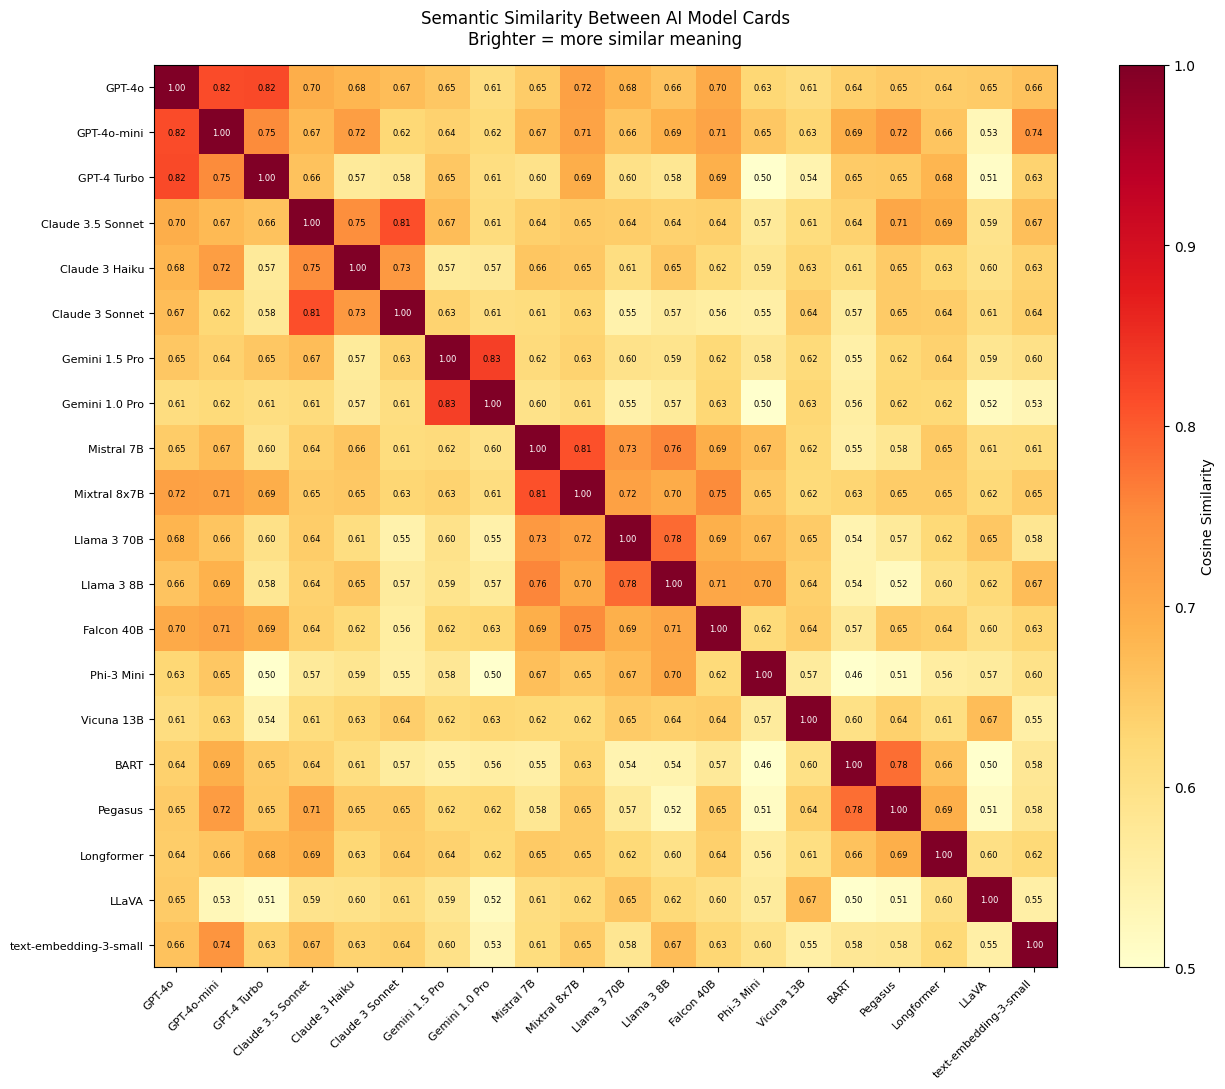


── Most semantically similar model pairs (excluding self) ─
  0.829 ████████████████      Gemini 1.5 Pro  ↔  Gemini 1.0 Pro
  0.818 ████████████████      GPT-4o  ↔  GPT-4 Turbo
  0.816 ████████████████      GPT-4o  ↔  GPT-4o-mini
  0.812 ████████████████      Claude 3.5 Sonnet  ↔  Claude 3 Sonnet
  0.810 ████████████████      Mistral 7B  ↔  Mixtral 8x7B
  0.785 ███████████████       Llama 3 70B  ↔  Llama 3 8B
  0.780 ███████████████       BART  ↔  Pegasus
  0.757 ███████████████       Mistral 7B  ↔  Llama 3 8B

💡  OBSERVE: Notice: summarisation-focused models (BART, Pegasus, Haiku) cluster together. Open-source models (Mistral, Llama, Falcon) form another cluster. This is why retrieval works — similar meaning → similar vector → found together.



In [12]:
# ── Cosine similarity heatmap — one vector per model card ─────────────────────
section("Cosine Similarity Heatmap — all 20 model cards")

# Average chunk embeddings per card to get one vector per card
card_vectors = {}
for chunk in all_chunks:
    did = chunk["doc_id"]
    if did not in card_vectors:
        card_vectors[did] = []
    card_vectors[did].append(chunk["embedding"])

doc_ids  = [c["doc_id"] for c in MODEL_CARDS]
labels   = [c["model"]  for c in MODEL_CARDS]
card_embs = np.array([
    np.mean(card_vectors[did], axis=0) for did in doc_ids
])

# Normalise → cosine similarity = dot product
norms   = np.linalg.norm(card_embs, axis=1, keepdims=True)
normed  = card_embs / norms
sim_mat = normed @ normed.T

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(sim_mat, cmap="YlOrRd", vmin=0.5, vmax=1.0)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

# Annotate cells
for i in range(len(labels)):
    for j in range(len(labels)):
        val = sim_mat[i, j]
        colour = "white" if val > 0.85 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=6, color=colour)

plt.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_title("Semantic Similarity Between AI Model Cards\n"
             "Brighter = more similar meaning", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("week4_similarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Print top similar pairs ────────────────────────────────────────────────────
section("Most semantically similar model pairs (excluding self)")
pairs = []
for i in range(len(labels)):
    for j in range(i+1, len(labels)):
        pairs.append((sim_mat[i,j], labels[i], labels[j]))
pairs.sort(reverse=True)
for score, a, b in pairs[:8]:
    bar = "█" * int(score * 20)
    print(f"  {score:.3f} {bar:<20}  {a}  ↔  {b}")

observe("Notice: summarisation-focused models (BART, Pegasus, Haiku) cluster together. "
        "Open-source models (Mistral, Llama, Falcon) form another cluster. "
        "This is why retrieval works — similar meaning → similar vector → found together.")

---
## Step 4 — Vector DB: Building the Chroma Index

We store all chunk embeddings in **Chroma** — an open-source vector database.  
Chroma persists the index locally and stores metadata (`doc_id`, `model`, `provider`) alongside each vector.

At query time, Chroma converts the query to an embedding and finds the nearest chunk vectors in milliseconds.

In [13]:
banner("Building Chroma Vector Index")

chroma_client = chromadb.PersistentClient(path="./chroma_week4")

# Drop and recreate for a clean demo run
try:
    chroma_client.delete_collection("model_cards")
except Exception:
    pass

collection = chroma_client.create_collection(
    name="model_cards",
    metadata={"hnsw:space": "cosine"}   # cosine similarity index
)

collection.add(
    ids        = [c["chunk_id"]  for c in all_chunks],
    embeddings = [c["embedding"].tolist() for c in all_chunks],
    documents  = [c["text"]      for c in all_chunks],
    metadatas  = [
        {"doc_id": c["doc_id"], "model": c["model"], "provider": c["provider"]}
        for c in all_chunks
    ]
)

success(f"Chroma index ready — {collection.count()} chunks indexed")
print(f"  Collection : model_cards")
print(f"  Distance   : cosine")
print(f"  Persist    : ./chroma_week4/")
print()

def embed_query(query: str) -> list:
    """Embed a single query string using OpenAI."""
    resp = oai.embeddings.create(model=EMBED_MODEL, input=[query])
    return resp.data[0].embedding

observe("The index is now a searchable map of meaning. "
        "Every chunk lives at a position in 1,536-dimensional space. "
        "A query lands near the chunks that share its meaning.")


═════════════════════════════════════════════════════════════════
  Building Chroma Vector Index
═════════════════════════════════════════════════════════════════


✅  Chroma index ready — 71 chunks indexed

  Collection : model_cards
  Distance   : cosine
  Persist    : ./chroma_week4/


💡  OBSERVE: The index is now a searchable map of meaning. Every chunk lives at a position in 1,536-dimensional space. A query lands near the chunks that share its meaning.



---
## Step 5 — Pure Retrieval Pipeline

Three stages — each one prints its results so you see the results **changing**:

```
Query
  → Stage A: Chroma semantic search     (top 8 by cosine similarity)
  → Stage B: BM25 hybrid re-score       (keyword overlap re-ranks)
  → Stage C: Cross-encoder rerank       (deep relevance model, top 3)
```

No generation yet — **exact text from the model cards only**.

In [ ]:
# ── Load cross-encoder (tiny, CPU-friendly) ───────────────────────────────────
section("Loading cross-encoder reranker...")
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
success("Cross-encoder ready (ms-marco-MiniLM-L-6-v2)")

# ── BM25 index over all chunks ────────────────────────────────────────────────
tokenised_corpus = [c["text"].lower().split() for c in all_chunks]
bm25 = BM25Okapi(tokenised_corpus)
success(f"BM25 index built over {len(all_chunks)} chunks")

In [ ]:
def retrieve_pipeline(query: str, semantic_k: int = 8, final_k: int = 3,
                      verbose: bool = True):
    """
    Full 3-stage retrieval pipeline.
    Returns list of top final_k chunk dicts with scores.
    """
    if verbose:
        banner(f"Retrieval Pipeline")
        print(f"  Query: {query}\n")

    # ── Stage A: Chroma semantic search ───────────────────────────────────────
    q_emb = embed_query(query)
    results = collection.query(
        query_embeddings=[q_emb],
        n_results=semantic_k,
        include=["documents", "metadatas", "distances"]
    )

    stage_a = []
    for i in range(len(results["ids"][0])):
        stage_a.append({
            "chunk_id":  results["ids"][0][i],
            "doc_id":    results["metadatas"][0][i]["doc_id"],
            "model":     results["metadatas"][0][i]["model"],
            "provider":  results["metadatas"][0][i]["provider"],
            "text":      results["documents"][0][i],
            "cosine_sim": 1 - results["distances"][0][i],
        })

    if verbose:
        section(f"Stage A — Chroma Semantic Search (top {semantic_k})")
        for r in stage_a:
            bar = "█" * int(r['cosine_sim'] * 20)
            print(f"  [{r['doc_id']}] {r['model']:<25} sim={r['cosine_sim']:.3f} {bar}")
            print(f"         {r['text'][:100]}...")
            print()

    # ── Stage B: BM25 hybrid re-score ─────────────────────────────────────────
    candidate_texts = [r["text"] for r in stage_a]
    tokenised_query = query.lower().split()

    # Get BM25 scores for the candidate texts (not the full corpus)
    # We find each candidate's position in all_chunks for proper BM25 scoring
    chunk_text_map = {c["text"]: idx for idx, c in enumerate(all_chunks)}
    bm25_scores_full = bm25.get_scores(tokenised_query)

    for r in stage_a:
        idx = chunk_text_map.get(r["text"], -1)
        bm25_score = bm25_scores_full[idx] if idx >= 0 else 0.0
        # Normalise BM25 to [0,1] range roughly
        r["bm25_score"] = bm25_score
        r["hybrid_score"] = 0.6 * r["cosine_sim"] + 0.4 * min(bm25_score / 10, 1.0)

    stage_b = sorted(stage_a, key=lambda x: x["hybrid_score"], reverse=True)

    if verbose:
        section("Stage B — BM25 Hybrid Re-score (semantic 60% + keyword 40%)")
        for r in stage_b:
            bar = "█" * int(r['hybrid_score'] * 20)
            print(f"  [{r['doc_id']}] {r['model']:<25} "
                  f"hybrid={r['hybrid_score']:.3f} "
                  f"(sem={r['cosine_sim']:.3f} bm25={r['bm25_score']:.2f}) {bar}")

    # ── Stage C: Cross-encoder rerank ─────────────────────────────────────────
    pairs = [(query, r["text"]) for r in stage_b]
    ce_scores = reranker.predict(pairs)

    for i, r in enumerate(stage_b):
        r["rerank_score"] = float(ce_scores[i])

    stage_c = sorted(stage_b, key=lambda x: x["rerank_score"], reverse=True)[:final_k]

    if verbose:
        section(f"Stage C — Cross-Encoder Rerank (top {final_k} final chunks)")
        for rank, r in enumerate(stage_c, 1):
            print(f"  Rank {rank} | [{r['doc_id']}] {r['model']} ({r['provider']})")
            print(f"  Rerank score: {r['rerank_score']:.4f}")
            print(f"  Exact text:")
            for line in textwrap.wrap(r["text"], width=90):
                print(f"    {line}")
            print()

        # Show unique doc IDs pulled
        unique_docs = list(dict.fromkeys(r["doc_id"] for r in stage_c))
        observe(f"Top {final_k} chunks came from {len(unique_docs)} doc ID(s): "
                f"{', '.join(unique_docs)} — "
                f"that's multi-source retrieval in action.")

    return stage_c

In [ ]:
# ── Demo Query 1 ──────────────────────────────────────────────────────────────
results_q1 = retrieve_pipeline(
    "Which model is best for summarising long documents?"
)

In [ ]:
# ── Demo Query 2 ──────────────────────────────────────────────────────────────
results_q2 = retrieve_pipeline(
    "What are my open source self-hostable options?"
)

In [ ]:
# ── Demo Query 3 ──────────────────────────────────────────────────────────────
results_q3 = retrieve_pipeline(
    "I need to process images and text together, which models support that?"
)

---
## Step 6 — Full RAG: Retrieval + Generation

Now we combine the pipeline:

1. **Retrieve** the top 3 chunks (Stage C above)
2. **Show the exact prompt** we're sending to GPT-4o-mini
3. **Compare** the cold answer (from Cell 0) vs the grounded RAG answer

This is the payoff moment.

In [ ]:
def build_rag_prompt(query: str, retrieved_chunks: list) -> tuple:
    """Build system + user messages for RAG generation. Returns (system, user)."""
    context_block = ""
    for i, chunk in enumerate(retrieved_chunks, 1):
        context_block += (
            f"[SOURCE {i} | {chunk['doc_id']} | {chunk['model']} | {chunk['provider']}]\n"
            f"{chunk['text']}\n\n"
        )

    system = (
        "You are an AI model advisor. Answer questions using ONLY the provided "
        "source documents. Cite the doc_id (e.g. MC-004) when referencing a source. "
        "If the answer is not in the sources, say so — do not guess."
    )
    user = (
        f"Context documents:\n\n{context_block}"
        f"Question: {query}\n\n"
        f"Answer based on the context above only:"
    )
    return system, user


def rag_answer(query: str, verbose_retrieval: bool = False) -> str:
    """Full RAG pipeline: retrieve → build prompt → generate → return answer."""
    chunks = retrieve_pipeline(query, verbose=verbose_retrieval)
    system, user = build_rag_prompt(query, chunks)
    answer = client.chat(CHAT_MODEL, system=system, user=user, temperature=0.0)
    return answer, chunks, system, user

In [ ]:
banner("Full RAG — The Payoff")

query = DEMO_QUERY  # same question from Cell 0

# ── Step 1: Retrieve ──────────────────────────────────────────────────────────
section("Step 1 of 3 — Retrieving relevant chunks")
grounded_answer, chunks, system_msg, user_msg = rag_answer(query, verbose_retrieval=False)

print(f"Retrieved {len(chunks)} chunks from: "
      f"{', '.join(c['doc_id'] + ' (' + c['model'] + ')' for c in chunks)}")

# ── Step 2: Show the prompt ───────────────────────────────────────────────────
section("Step 2 of 3 — Exact prompt sent to GPT-4o-mini")
print("SYSTEM:")
print(f"  {system_msg}")
print()
print("USER (first 600 chars):")
for line in user_msg[:600].splitlines():
    print(f"  {line}")
print("  ...")

observe("The model receives: query + exact source text + instruction to cite. "
        "It cannot hallucinate what isn't in the context.")

# ── Step 3: Side-by-side comparison ──────────────────────────────────────────
section("Step 3 of 3 — Cold vs RAG Answer")
compare(
    "❌  COLD (no context — hallucination risk)", cold_answer,
    "✅  RAG  (grounded in model cards)",          grounded_answer
)

discuss(
    "What's different? The RAG answer cites specific doc IDs. "
    "It mentions exact context windows and pricing from our cards. "
    "The cold answer may have been confident but unverifiable. "
    "RAG makes the model's sources visible — and auditable."
)

---
## Step 7 — Why Different Techniques? The Full Picture

Today you saw three of these four in action. The fourth arrives in Week 5 (Neo4j).

In [ ]:
banner("RAG Technique Comparison")

comparison = pd.DataFrame([
    {
        "Technique":      "Basic Semantic Search",
        "How it works":   "Embed query → find nearest vectors in Chroma",
        "Best for":       "General meaning-based retrieval",
        "Weakness":       "Misses exact keyword matches (e.g. 'GPT-4o-mini')",
        "Seen today":     "✅ Stage A"
    },
    {
        "Technique":      "Hybrid (Vector + BM25)",
        "How it works":   "Combine cosine similarity score with BM25 keyword score",
        "Best for":       "Queries mixing meaning AND exact terms",
        "Weakness":       "Tuning the blend ratio (60/40 here) requires experimentation",
        "Seen today":     "✅ Stage B"
    },
    {
        "Technique":      "Cross-Encoder Reranking",
        "How it works":   "Deep model scores (query, chunk) pairs for true relevance",
        "Best for":       "Promoting the *most* relevant chunk to rank 1",
        "Weakness":       "Slower — only feasible on top-N candidates, not full corpus",
        "Seen today":     "✅ Stage C"
    },
    {
        "Technique":      "Multi-Query",
        "How it works":   "LLM generates 3–5 query variants → retrieve for each → merge",
        "Best for":       "Ambiguous questions with multiple valid phrasings",
        "Weakness":       "Extra LLM calls per query — higher latency and cost",
        "Seen today":     "⏭️  Week 5"
    },
    {
        "Technique":      "Graph RAG (Neo4j)",
        "How it works":   "Traverse knowledge graph relationships instead of vector search",
        "Best for":       "Structured relationships: 'which models support X AND Y'",
        "Weakness":       "Requires upfront schema and graph construction",
        "Seen today":     "⏭️  Week 5"
    },
])

pd.set_option("display.max_colwidth", 60)
display(comparison)

observe(
    "Today covered the first 3 techniques — semantic, hybrid, and reranking — "
    "on a real corpus with real OpenAI embeddings. "
    "Week 5: 30 mins on Neo4j graph RAG for relationship-based retrieval."
)

---
## Session Summary

| Concept | What you saw |
|---------|-------------|
| **Why RAG** | Cold LLM hallucinated; RAG answered with cited sources |
| **Corpus** | 20 AI model cards, 4 deliberate overlap themes |
| **Chunking** | 300-char chunks, 50-char overlap — pandas table |
| **Embeddings** | OpenAI `text-embedding-3-small`, 1,536 dims, cosine heatmap |
| **Vector DB** | Chroma, cosine distance, persistent index |
| **Hybrid retrieval** | Chroma (semantic) + BM25 (keyword) combined |
| **Reranking** | Cross-encoder promoted the truly relevant chunk to rank 1 |
| **Generation** | GPT-4o-mini answered from exact retrieved context, cited doc IDs |

**Next: Week 5 — Neo4j Graph RAG (30 min)**  
When the question is *"which models support multimodal AND are open source?"*,  
vector search struggles. Graph traversal answers it directly.